# TP Final - PINN para la ecuacion de Helmholtz 2D

Replica simplificada del paper de Wang, Teng y Perdikaris (2021), donde aplicamos **solo la primera mejora**: el balance adaptativo de gradientes durante backprop.

## Indice

1. Setup (imports)
2. El problema: PDE y solucion exacta
3. Samplers de puntos (interior y borde)
4. La red neuronal
5. Derivadas con autograd
6. **Experimento M1**: PINN sin balance (baseline)
7. **Experimento M2**: PINN con balance (la mejora del paper)
8. **Experimento FD**: diferencias finitas (control numerico)
9. Corte 1D para comparar
10. **Adam vs Adam + LBFGS**
11. **Grid search de hiperparametros**
12. Resumen final

# 1. Setup

Lo primero es traer las herramientas que vamos a usar:

- **numpy**: para hacer cuentas con arrays de numeros (vectores, matrices). Es la base de casi todo Python cientifico.
- **torch**: la libreria de redes neuronales que vamos a usar. Nos da la red, el optimizador (Adam), y lo mas importante: el **autograd**, que es lo que calcula derivadas automaticamente.
- **matplotlib**: para hacer todos los graficos.
- **scipy.sparse**: para resolver el sistema lineal grande pero "vacio" del solver de diferencias finitas. Trabajar con matrices dispersas es mucho mas rapido que con matrices densas cuando hay millones de ceros.
- **itertools**: nos da `product()` para iterar todas las combinaciones del grid search.

In [1]:
import numpy as np                       # arrays, cuentas, algebra lineal
import torch                              # backend de redes neuronales (CPU/GPU)
import torch.nn as nn                     # capas de la red (Linear, etc.) + funciones de init
import matplotlib.pyplot as plt           # graficos
import scipy.sparse as sp                 # matrices dispersas (para el solver FD)
import scipy.sparse.linalg as spla        # resolver A x = b cuando A es dispersa
import itertools                          # combinaciones para el grid search

In [2]:
# Fijamos las "semillas" del generador de numeros aleatorios.
# Asi, cada vez que corramos este notebook, los numeros aleatorios
# (puntos muestreados, pesos iniciales de la red) son SIEMPRE los mismos.
# Sin esto, cada corrida daria un resultado distinto y no podriamos
# comparar entre cosas.
np.random.seed(0)        # para numpy (samplers)
torch.manual_seed(0)     # para torch (pesos iniciales de la red)

# 2. El problema

Vamos a resolver la **ecuacion de Helmholtz en 2D**. Esta ecuacion aparece en fisica cuando estudiamos ondas que oscilan a una sola frecuencia (acustica, electromagnetismo, vibraciones). En lenguaje matematico se ve asi:

$$\Delta u + \lambda \, u = q(x, y)$$

Las partes son:

- $u(x, y)$ es la **incognita**: lo que queremos encontrar. Es una funcion que asigna un numero a cada punto $(x, y)$ del plano.
- $\Delta u$ se llama "Laplaciano" y significa $\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}$, o sea **las segundas derivadas de u sumadas**. Mide la "curvatura" de la funcion en cada punto.
- $\lambda$ es una constante (en nuestro caso vale 1).
- $q(x, y)$ es el **forcing** o "fuente": un dato del problema que dice cuanto vale el lado derecho en cada punto.

El dominio es el cuadrado $[-1, 1]^2$ (o sea $x$ entre $-1$ y $+1$, $y$ entre $-1$ y $+1$). En los 4 bordes del cuadrado pedimos $u = 0$.

## Como verificamos si la solucion es correcta

Aca usamos un truco clasico: en vez de tomar un $q$ cualquiera y ver que sale, **inventamos primero la solucion** y despues calculamos que $q$ haria falta para que esa solucion cumpla la ecuacion. Esto se llama "metodo de las soluciones fabricadas" (manufactured solutions).

La que elegimos es:

$$u_{\text{exacta}}(x, y) = \sin(\pi x) \cdot \sin(4\pi y)$$

Tiene varias propiedades buenas:

1. **Vale cero en los bordes** automaticamente: $\sin(\pi \cdot \pm 1) = 0$ y $\sin(4\pi \cdot \pm 1) = 0$.
2. Tiene **1 onda en x** y **4 ondas en y**. Esa asimetria (mucho mas rapida en y que en x) es lo que hace dificil el problema y por eso el paper lo eligio: las altas frecuencias en y son las que rompen al PINN sin balance.

Definamos primero las constantes que vienen del paper:

In [3]:
LAMBDA = 1.0    # constante de la PDE (es el "lambda" de Delta u + lambda u = q)
A1 = 1.0        # frecuencia espacial en x  ->  1 onda completa entre x=-1 y x=1
A2 = 4.0        # frecuencia espacial en y  ->  4 ondas en y (esto es lo dificil)

La funcion `u_exacta` toma un array de puntos y devuelve $u(x, y)$ en cada uno. Si le pasamos 100 puntos, nos da un array de 100 valores.

In [4]:
def u_exacta(x):
    # x es un array con shape (N, 2): N filas, 2 columnas (la coord x y la coord y).
    # x[:, 0:1] toma la columna 0 (la x) manteniendo la forma (N, 1).
    # x[:, 1:2] toma la columna 1 (la y).
    # Aplicamos sin(pi x) * sin(4 pi y) elemento por elemento.
    return np.sin(A1 * np.pi * x[:, 0:1]) * np.sin(A2 * np.pi * x[:, 1:2])

In [5]:
# Probamos en 4 puntos que estan SOBRE los bordes del cuadrado.
# Esperamos que de 0 en los 4 (porque sin(pi * +/-1) = 0).
puntos_borde = np.array([[-1, 0.5], [1, 0.5], [0.5, -1], [0.5, 1]])
u_exacta(puntos_borde).flatten()

array([ 2.99951957e-32, -2.99951957e-32,  4.89858720e-16, -4.89858720e-16])

## El forcing

Ahora calculamos que $q$ haria falta para que $u_{\text{exacta}}$ cumpla la ecuacion. Hacemos la cuenta a mano (derivando dos veces):

- $\frac{\partial^2}{\partial x^2}[\sin(\pi x) \sin(4\pi y)] = -\pi^2 \sin(\pi x) \sin(4\pi y) = -\pi^2 \cdot u$
- $\frac{\partial^2}{\partial y^2}[\sin(\pi x) \sin(4\pi y)] = -(4\pi)^2 \sin(\pi x) \sin(4\pi y) = -16\pi^2 \cdot u$

Entonces:

$$q(x, y) = u_{xx} + u_{yy} + \lambda u = (-\pi^2 - 16\pi^2 + \lambda) \cdot u_{\text{exacta}}$$

Notar: $q$ es **proporcional a $u_{\text{exacta}}$** con un factor constante $(-\pi^2 - 16\pi^2 + \lambda) \approx -167$. Eso significa que el forcing es **enorme** comparado con $u$ (~167× mas grande en magnitud), y esa es justamente la razon por la que las PINN sufren: la perdida del residuo tiene magnitudes gigantes y "ahoga" a la perdida del borde.

In [6]:
def forcing(x):
    # Aplicamos la cuenta de arriba: q = (-pi^2 - 16 pi^2 + lambda) * u_exacta
    factor = -(A1 * np.pi)**2 - (A2 * np.pi)**2 + LAMBDA
    return factor * u_exacta(x)

## Visualizemos la solucion

Para "ver" $u_{\text{exacta}}$ tenemos que armar una **grilla** de puntos sobre el cuadrado y evaluar $u$ en cada uno. Es como sacar muchas fotos del campo $u$ a intervalos regulares.

Usamos `meshgrid`, que es la forma estandar de numpy de armar grillas 2D:

- `x` e `y` son arrays 1D con 100 puntos cada uno (los ejes).
- `meshgrid(x, y)` los expande a **matrices 2D** donde cada elemento es una coordenada.

In [7]:
n = 100                                     # grilla de 100 x 100 puntos
x = np.linspace(-1, 1, n)                   # 100 valores entre -1 y 1, igualmente espaciados
y = np.linspace(-1, 1, n)
X1, X2 = np.meshgrid(x, y)                  # X1 y X2 son matrices (100, 100) con coords (x, y)

# Aplastamos las dos matrices a una lista de puntos (10000 puntos, cada uno con sus 2 coords).
# np.column_stack pone los dos vectores en columnas, asi queda shape (10000, 2).
puntos = np.column_stack([X1.flatten(), X2.flatten()])

In [8]:
# Evaluamos u_exacta y forcing en los 10000 puntos y volvemos a darle forma 2D (100x100)
# para poder graficarlos con pcolormesh.
u_real_2d = u_exacta(puntos).reshape(n, n)
q_real_2d = forcing(puntos).reshape(n, n)

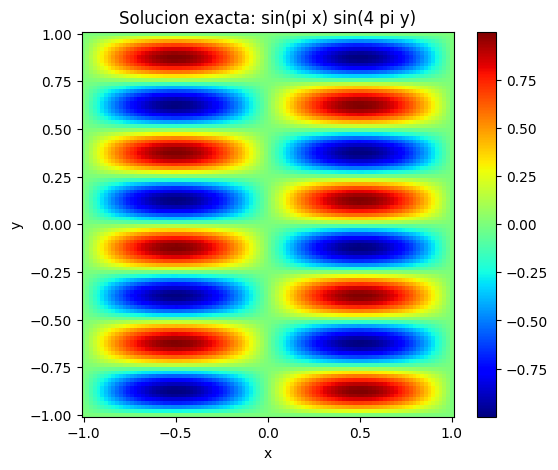

In [9]:
# Plot de la solucion exacta.
# pcolormesh pinta una celda de color por cada punto de la grilla.
# cmap="jet": paleta de colores rojo-azul (clasica para fisica).
plt.figure(figsize=(6, 5))
plt.pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
plt.colorbar()                              # barra lateral con los valores
plt.xlabel("x"); plt.ylabel("y")
plt.title("Solucion exacta: sin(pi x) sin(4 pi y)")
plt.show()

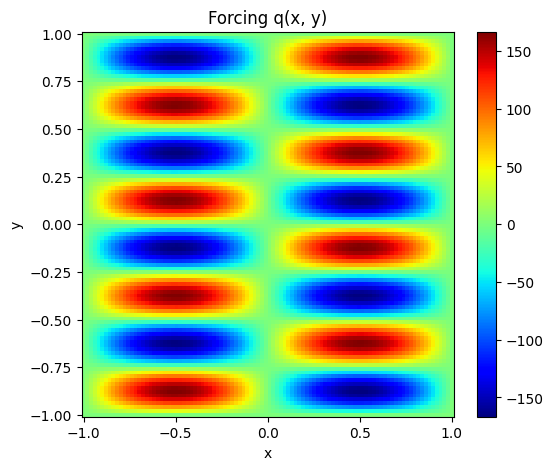

In [10]:
# Plot del forcing q. Mismo patron que u_exacta pero amplificado ~167 veces
# (porque q = factor * u con factor ~ -167).
plt.figure(figsize=(6, 5))
plt.pcolormesh(X1, X2, q_real_2d, cmap="jet", shading="auto")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("y")
plt.title("Forcing q(x, y)")
plt.show()

## Vista 3D de la solucion exacta

Lo mismo que arriba pero en 3D, donde la altura es el valor de $u$. Aca se ven mejor las **4 oscilaciones en y** y la asimetria del problema (la solucion ondula mucho mas rapido en y que en x). Esa anisotropia es lo que vuelve dificil el problema.

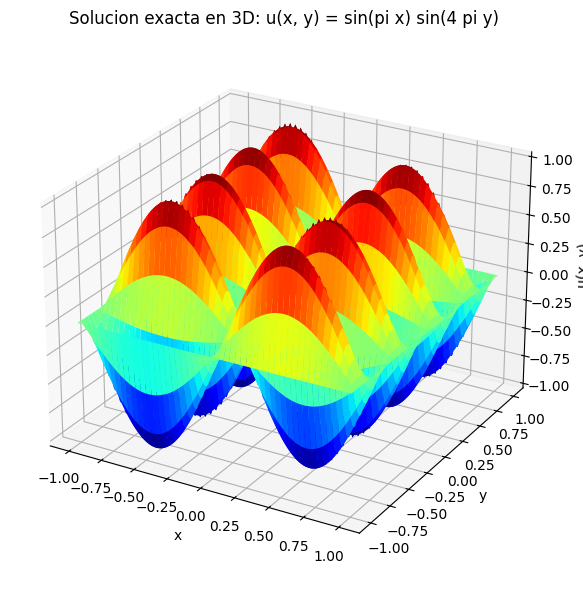

In [11]:
# Plot 3D de la solucion exacta. El eje Z es el valor de u(x, y).
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")     # 3d activa la proyeccion en perspectiva

# plot_surface dibuja una "sabana" 3D usando la grilla X1, X2 y la altura u_real_2d.
# rstride/cstride saltan filas y columnas para que el plot sea mas liviano.
# edgecolor="none" saca las lineas negras (mas limpio visualmente).
ax.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u(x, y)")
ax.set_title("Solucion exacta en 3D: u(x, y) = sin(pi x) sin(4 pi y)")
ax.view_init(elev=25, azim=-60)                 # angulo de camara
plt.tight_layout()
plt.show()

# 3. Samplers de puntos

Una PINN no tiene un "dataset" como una red comun. **Lo que hace es:**

- Toma muchos puntos del dominio (al azar).
- En cada uno calcula que tan bien se cumple la PDE o el borde.
- Suma todos esos errores y los minimiza.

A los puntos donde forzamos la PDE se les dice **puntos de colocacion**. Lo importante: cada iteracion del entrenamiento usa **puntos nuevos**. Eso es como hacer "data augmentation": damos mas variedad y la red generaliza mejor al dominio continuo.

Tenemos dos lugares donde queremos forzar cosas:

| Lugar | Que forzamos | Para que |
|-------|---------------|----------|
| **Interior** (cualquier punto dentro de $[-1,1]^2$) | $u_{xx} + u_{yy} + \lambda u = q(x, y)$ | que la red satisfaga la PDE |
| **Borde** (los 4 lados del cuadrado) | $u = 0$ | que la red respete la condicion de contorno |

In [12]:
def muestrear_interior(n):
    # n puntos al azar en el cuadrado [-1, 1] x [-1, 1].
    # np.random.uniform(a, b, shape) -> numeros uniformes entre a y b.
    # size=(n, 2): n filas, 2 columnas (x e y).
    return np.random.uniform(-1, 1, size=(n, 2))

In [13]:
def muestrear_borde(n):
    # n puntos sobre los 4 bordes. Repartimos n/4 puntos por borde.
    m = n // 4

    # Borde inferior: y = -1, x al azar entre -1 y 1.
    abajo = np.column_stack([np.random.uniform(-1, 1, m), -np.ones(m)])
    # Borde superior: y = +1
    arriba = np.column_stack([np.random.uniform(-1, 1, m), np.ones(m)])
    # Borde izquierdo: x = -1, y al azar.
    izq = np.column_stack([-np.ones(m), np.random.uniform(-1, 1, m)])
    # Borde derecho: x = +1.
    der = np.column_stack([np.ones(m), np.random.uniform(-1, 1, m)])

    # Apilamos los 4 grupos en un solo array (n filas, 2 columnas).
    return np.vstack([abajo, arriba, izq, der])

Veamos un ejemplo de muestreo:

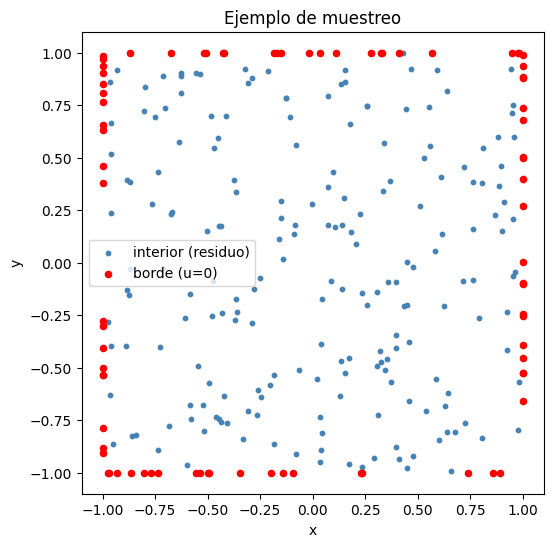

In [14]:
# Tomamos un batch de prueba para ver como queda visualmente.
pts_int = muestrear_interior(200)           # 200 puntos al azar adentro
pts_bnd = muestrear_borde(80)               # 80 puntos al azar sobre los bordes

plt.figure(figsize=(6, 6))
# scatter dibuja cada punto. s = tamano del marker, c = color.
plt.scatter(pts_int[:, 0], pts_int[:, 1], s=10, c="steelblue", label="interior (residuo)")
plt.scatter(pts_bnd[:, 0], pts_bnd[:, 1], s=20, c="red", label="borde (u=0)")
plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)   # margen visual de 0.1 a cada lado
plt.xlabel("x"); plt.ylabel("y")
plt.title("Ejemplo de muestreo")
plt.legend()
plt.gca().set_aspect("equal")               # que x e y tengan la misma escala (sino el cuadrado se ve rectangular)
plt.show()

# 4. La red neuronal

Vamos a construir un **MLP** (Multi-Layer Perceptron), que es la red neuronal mas basica:

- **Capas lineales** intercaladas con **funciones de activacion tanh**.
- Si la pasamos `[2, 50, 50, 50, 1]`, significa: 2 entradas (las coordenadas $x, y$) -> 50 neuronas -> 50 -> 50 -> 1 salida (el valor de $u$ en ese punto).

Una capa lineal `nn.Linear(50, 50)` hace internamente:

$$\text{salida} = W \cdot \text{entrada} + b$$

donde $W$ es una matriz 50x50 (los pesos) y $b$ un vector de 50 numeros (los sesgos). Cuando creamos la red, $W$ y $b$ arrancan con valores aleatorios y el entrenamiento los ajusta.

**Por que tanh entre medio?** Si solo tuvieramos capas lineales, toda la red seria una funcion lineal (no podria aproximar $\sin$). Necesitamos no-linealidades. `tanh(x)` es una de las clasicas: aplasta los valores a $[-1, 1]$ y es suave (derivable).

**Que es Xavier init?** Es una formula que pone los pesos iniciales con la varianza justa para que la senal pase bien de capa en capa. Sin ella, los gradientes se "apagan" o "explotan" en redes profundas.

In [15]:
class PINN(nn.Module):
    # Toda red en PyTorch hereda de nn.Module.
    # Tenemos que definir 2 cosas: __init__ (construir las capas) y forward (que hace con un input).

    def __init__(self, capas):
        super().__init__()                          # llamada obligatoria a la clase padre
        # ModuleList es una lista que PyTorch "ve": registra automaticamente los pesos
        # de cada capa como parametros entrenables.
        self.capas = nn.ModuleList()
        # Vamos creando capas lineales: de capas[i] entradas a capas[i+1] salidas.
        for i in range(len(capas) - 1):
            self.capas.append(nn.Linear(capas[i], capas[i + 1]))

        # Inicializamos cada capa con Xavier normal (pesos balanceados).
        for capa in self.capas:
            nn.init.xavier_normal_(capa.weight)     # pesos W ~ N(0, std calculada)
            nn.init.zeros_(capa.bias)               # bias b empiezan en 0

    def forward(self, x):
        # x: tensor con shape (batch, 2). Le pasamos cada par (x, y) y sale u.

        # Aplicamos tanh DESPUES de cada capa, MENOS la ultima.
        # capas[:-1] = todas menos la ultima.
        for capa in self.capas[:-1]:
            x = torch.tanh(capa(x))

        # La ultima capa es lineal (sin tanh) porque la salida u puede tomar
        # cualquier valor real, no queremos restringirla a [-1, 1].
        return self.capas[-1](x)

Probamos la red sin entrenar para ver que tipo de salida da (deberian ser numeros random ya que los pesos arrancan random):

In [16]:
red_prueba = PINN([2, 50, 50, 50, 1])                  # 2 -> 50 -> 50 -> 50 -> 1
x_prueba = torch.tensor([[0.5, 0.5], [-0.3, 0.7]], dtype=torch.float32)  # 2 puntos de prueba
# .detach(): saca el tensor del grafo de autograd (no nos interesan derivadas aca).
# .numpy(): convierte a numpy.
# .flatten(): aplana de (2, 1) a (2,) para verlo lindo.
red_prueba(x_prueba).detach().numpy().flatten()

array([0.1484845 , 0.16963337], dtype=float32)

In [17]:
# Cuantos parametros tiene la red. red.parameters() son W y b de cada capa.
# .numel() = numero de elementos. Sumamos todos.
# Para [2, 50, 50, 50, 1]:  2*50 + 50  +  50*50 + 50  +  50*50 + 50  +  50*1 + 1  =  5301
sum(p.numel() for p in red_prueba.parameters())

5301

# 5. Derivadas con autograd (lo magico de las PINN)

**Esta seccion es CLAVE para entender PINNs.**

Pensemos: nuestra red es una funcion $u_\theta(x, y)$ (donde $\theta$ son los pesos). Para checkear si cumple la PDE necesitamos calcular $u_{xx}$, $u_{yy}$. Pero la red no nos da una formula explicita de $u$ — es solo un grafo de matrices y `tanh`.

**Aca entra autograd.** PyTorch guarda un "grafo computacional" de todas las operaciones que se hicieron para producir $u$. Despues, si le pedimos "derivame $u$ respecto a $x$", **rastrea ese grafo hacia atras** aplicando la regla de la cadena automaticamente. Es como derivar a mano pero lo hace solo, sin que escribamos las formulas.

Para que esto funcione necesitamos 2 cosas:

1. La entrada (las coordenadas $x$, $y$) tiene que tener `requires_grad=True`. Eso le dice a PyTorch: "guarda como derivar respecto a esto".
2. Cuando llamamos `torch.autograd.grad`, le pasamos `create_graph=True` si queremos **derivar otra vez** (porque para $u_{xx}$ tenemos que derivar $u_x$ otra vez respecto a $x$, o sea hacer 2 derivaciones encadenadas).

Definamos una funcion helper que hace una derivacion:

In [18]:
def derivada(salida, entrada):
    # Calcula d(salida)/d(entrada). Devuelve un tensor con la misma forma que `entrada`.
    return torch.autograd.grad(
        salida,                                # lo que vamos a derivar (numerador)
        entrada,                               # respecto a que derivar (denominador)
        grad_outputs=torch.ones_like(salida),  # truco para batches: derivar la SUMA cuando hay varios puntos
        create_graph=True,                     # IMPORTANTE: nos permite derivar otra vez despues (u_xx)
    )[0]                                       # autograd.grad devuelve una tupla; tomamos el primer elemento

## El residuo de la PDE

Definimos una funcion que calcula $u_{xx} + u_{yy} + \lambda u$ (el lado izquierdo de la ecuacion de Helmholtz) usando autograd. Si la red aprendio bien, **esto deberia ser casi igual al forcing $q$ en cada punto**.

El error $r - q$ es lo que vamos a minimizar (lo llamamos "residuo" porque cuanto mas chico, mejor cumple la PDE).

In [19]:
def calcular_residuo(red, puntos):
    # Separamos las coordenadas x e y. Necesitamos hacerlas tensores INDEPENDIENTES
    # con requires_grad=True para poder derivar respecto a cada una.
    #
    # .clone() copia, .detach() la saca del grafo viejo, .requires_grad_(True) la marca
    # como "derivable". Es el patron estandar.
    x = puntos[:, 0:1].clone().detach().requires_grad_(True)
    y = puntos[:, 1:2].clone().detach().requires_grad_(True)

    # Concatenamos x e y de vuelta en (N, 2) para pasarselo a la red.
    # Llamada a la red -> obtenemos u(x, y).
    u = red(torch.cat([x, y], dim=1))

    # Primeras derivadas: u_x = du/dx,  u_y = du/dy.
    u_x = derivada(u, x)
    u_y = derivada(u, y)

    # Segundas derivadas: u_xx = d(u_x)/dx,  u_yy = d(u_y)/dy.
    # Aca es donde "derivamos otra vez" — y por eso necesitabamos create_graph=True.
    u_xx = derivada(u_x, x)
    u_yy = derivada(u_y, y)

    # Devolvemos el lado izquierdo de la PDE.
    return u_xx + u_yy + LAMBDA * u

# 6. Experimento M1: PINN sin balance (baseline)

Este es el "PINN original" tal como lo propuso Raissi en 2019. **Lo entrenamos para sentirle la falla.**

La idea:

1. Calculamos dos perdidas:
   - $L_{res}$ = $(u_{xx} + u_{yy} + \lambda u - q)^2$, promediado sobre los puntos del interior. Mide cuanto se incumple la PDE.
   - $L_{bc}$ = $(u - 0)^2$, promediado sobre los puntos del borde. Mide cuanto se incumple la condicion de borde.
2. **Sumamos las dos**: $L = L_{res} + L_{bc}$.
3. Damos un paso de Adam para bajar $L$.

**Que esperamos**: como $q$ tiene magnitud ~167 (vimos antes), $L_{res}$ es enorme comparada con $L_{bc}$. Adam va a priorizar bajar $L_{res}$ y se va a olvidar del borde. **Resultado: error grande en los bordes**.

In [20]:
# Reseteamos las seeds para que esta corrida sea reproducible
# (si lo corremos varias veces, los pesos iniciales son los mismos).
np.random.seed(0); torch.manual_seed(0)

# Creamos la red M1: 3 capas ocultas de 50 neuronas (igual al repo del paper).
red_m1 = PINN([2, 50, 50, 50, 1])

In [21]:
# Optimizador Adam. lr=1e-3 es el learning rate inicial (igual al paper).
# Adam es el optimizador estandar para redes neuronales: adapta la tasa de aprendizaje
# por parametro segun la historia de gradientes.
optimizador_m1 = torch.optim.Adam(red_m1.parameters(), lr=1e-3)

# El paper usa "learning rate exponential decay": el lr se multiplica por 0.9 cada 1000 pasos.
# Para que decaiga gradualmente en CADA paso, calculamos cuanto vale 0.9^(1/1000):
factor_decay = 0.9 ** (1.0 / 1000)             # ~ 0.99989

# ExponentialLR multiplica el lr por `gamma` en cada paso.
scheduler_m1 = torch.optim.lr_scheduler.ExponentialLR(optimizador_m1, gamma=factor_decay)

In [22]:
# Diccionario donde vamos a ir guardando como evolucionan las perdidas durante el entrenamiento.
# Despues lo usamos para hacer la curva de loss.
hist_m1 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}

## Loop de entrenamiento

Este es el **corazon del PINN**. Lo vamos a hacer durante 40 000 iteraciones (como el paper). En cada iteracion:

1. **Muestreamos** un batch fresco de 128 puntos del interior y 128 del borde.
2. **Calculamos $L_{res}$**: pasamos los puntos del interior por la red, derivamos para obtener $u_{xx} + u_{yy} + \lambda u$, y restamos $q$. Promediamos al cuadrado.
3. **Calculamos $L_{bc}$**: pasamos los puntos del borde por la red, vemos si dan 0, promediamos al cuadrado.
4. **Sumamos** las dos perdidas: $L = L_{res} + L_{bc}$.
5. **Backward**: PyTorch calcula los gradientes de $L$ respecto a todos los pesos de la red.
6. **Step**: Adam usa esos gradientes para actualizar los pesos.

Cada 1000 iters imprimimos como van las dos perdidas, para ver el progreso en vivo.

In [23]:
batch = 128                   # cuantos puntos por mini-batch
n_iter = 40000                # iteraciones totales (como el paper)

for it in range(n_iter):
    # =====================================================================
    # PASO 1: muestreamos puntos NUEVOS en esta iteracion.
    # =====================================================================
    # muestrear_*() devuelve numpy. Lo convertimos a tensor de PyTorch float32.
    pts_int = torch.tensor(muestrear_interior(batch), dtype=torch.float32)  # 128 puntos interior
    pts_bnd = torch.tensor(muestrear_borde(batch), dtype=torch.float32)     # 128 puntos borde

    # =====================================================================
    # PASO 2: calculamos L_res (la red tiene que cumplir la PDE).
    # =====================================================================
    # q_obj = los valores VERDADEROS del forcing en esos puntos (calculados analiticamente).
    # forcing() es numpy, asi que convertimos el resultado a tensor.
    q_obj = torch.tensor(forcing(pts_int.numpy()), dtype=torch.float32)

    # r_pred = lo que la red dice que es u_xx + u_yy + lambda u en cada punto.
    # Esto usa autograd internamente (ver calcular_residuo arriba).
    r_pred = calcular_residuo(red_m1, pts_int)

    # L_res = promedio de (r_pred - q_obj)^2  (error cuadratico medio).
    L_res = ((r_pred - q_obj) ** 2).mean()

    # =====================================================================
    # PASO 3: calculamos L_bc (la red tiene que dar 0 en el borde).
    # =====================================================================
    u_pred_borde = red_m1(pts_bnd)        # u predicho en los puntos del borde
    L_bc = (u_pred_borde ** 2).mean()      # promedio de u^2 (deberia ser cero)

    # =====================================================================
    # PASO 4: perdida total = L_res + L_bc (SIN balance, esto es M1).
    # =====================================================================
    perdida = L_res + L_bc

    # =====================================================================
    # PASO 5: backward + step.
    # =====================================================================
    optimizador_m1.zero_grad()    # limpiamos los gradientes viejos (PyTorch los acumula sino)
    perdida.backward()             # calcula gradientes de la perdida respecto a TODOS los pesos
    optimizador_m1.step()          # Adam actualiza los pesos
    scheduler_m1.step()            # decae el learning rate un poquito

    # =====================================================================
    # PASO 6: guardar historial cada 10 iters (para graficar despues).
    # =====================================================================
    if it % 10 == 0:
        hist_m1["iter"].append(it)
        hist_m1["L_res"].append(L_res.item())     # .item() convierte tensor 0-d a float python
        hist_m1["L_bc"].append(L_bc.item())
        hist_m1["lambda_bc"].append(1.0)           # en M1 siempre es 1 (no hay balance)

    # =====================================================================
    # PASO 7: imprimir progreso cada 1000 iters.
    # =====================================================================
    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={L_res.item():.2e}  L_bc={L_bc.item():.2e}")

print("Listo M1.")

  iter     0  L_res=7.22e+03  L_bc=3.85e-02


  iter  1000  L_res=3.98e+03  L_bc=1.18e+01


  iter  2000  L_res=1.79e+02  L_bc=8.21e+00


  iter  3000  L_res=7.36e+01  L_bc=4.62e+00


  iter  4000  L_res=4.40e+01  L_bc=3.51e+00


...

  iter 36000  L_res=6.83e-01  L_bc=1.72e-01


  iter 37000  L_res=4.95e-01  L_bc=1.73e-01


  iter 38000  L_res=6.10e-01  L_bc=1.88e-01


  iter 39000  L_res=6.06e-01  L_bc=1.53e-01


Listo M1.


## Evaluamos M1

Pasamos los 10 000 puntos de la grilla por la red entrenada y comparamos con la solucion exacta. El **error L2 relativo** es la metrica estandar:

$$\text{error} = \frac{\|u_{\text{real}} - u_{\text{pred}}\|_2}{\|u_{\text{real}}\|_2}$$

Un valor de 0.1 significa "10% de error promedio".

In [24]:
# torch.no_grad(): le decimos a PyTorch que NO necesitamos gradientes aca (solo evaluamos).
# Esto es mas rapido y usa menos memoria.
with torch.no_grad():
    u_pred_m1 = red_m1(torch.tensor(puntos, dtype=torch.float32)).numpy().flatten()

# Reshape de vuelta a 2D para graficar.
u_pred_m1_2d = u_pred_m1.reshape(n, n)

# Error L2 relativo: norma(error) / norma(real).
error_m1 = np.linalg.norm(u_real_2d.flatten() - u_pred_m1) / np.linalg.norm(u_real_2d.flatten())
print(f"M1: error L2 relativo = {error_m1:.3e}")

M1: error L2 relativo = 4.595e-01


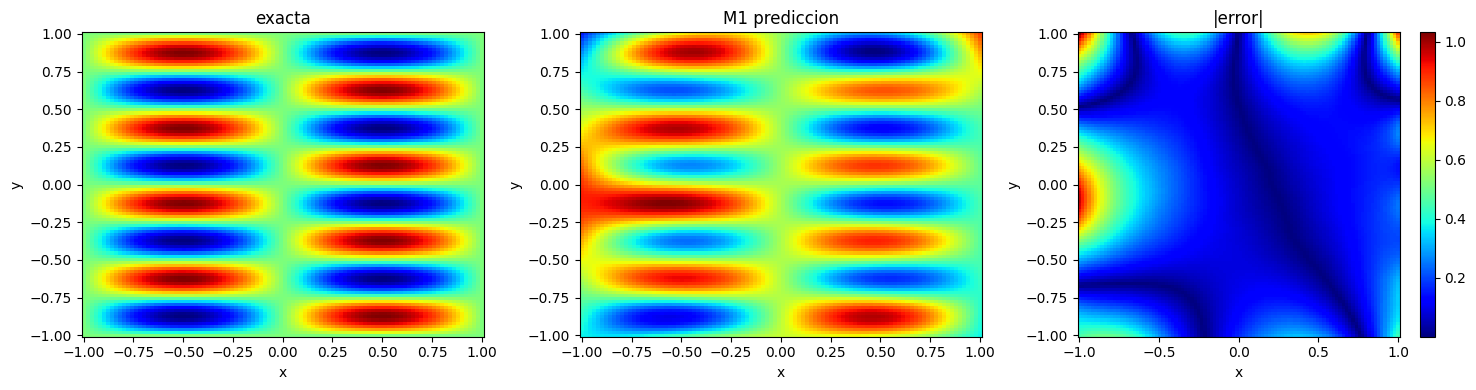

In [25]:
# Triptico: solucion exacta | prediccion M1 | error absoluto
# Esperamos ver que el error sea mas grande EN LOS BORDES (la patologia).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto");        axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m1_2d, cmap="jet", shading="auto");     axes[1].set_title("M1 prediccion")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m1_2d),
                        cmap="jet", shading="auto");                       axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])         # solo barra al ultimo subplot
plt.tight_layout()
plt.show()

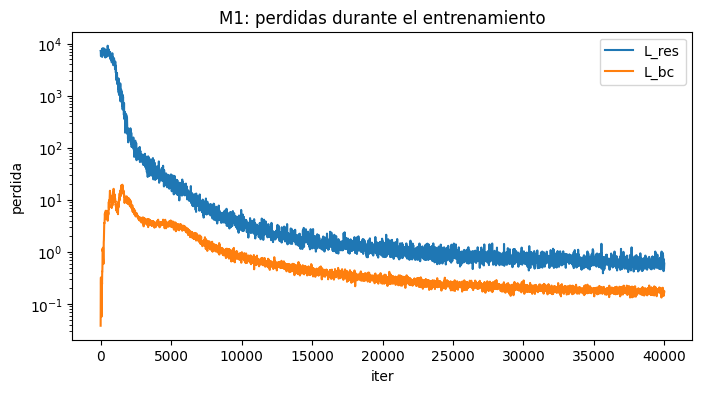

In [26]:
# Curva de las dos perdidas durante el entrenamiento.
# Escala log porque las perdidas bajan varios ordenes de magnitud.
plt.figure(figsize=(8, 4))
plt.plot(hist_m1["iter"], hist_m1["L_res"], label="L_res")
plt.plot(hist_m1["iter"], hist_m1["L_bc"], label="L_bc")
plt.yscale("log")
plt.xlabel("iter"); plt.ylabel("perdida")
plt.title("M1: perdidas durante el entrenamiento")
plt.legend()
plt.show()
# Observacion clave: L_bc se estanca rapido en un valor relativamente alto.
# Eso es la patologia: la red dejo de "trabajar" en el borde.

## La patologia visualizada (Figura 2 del paper)

Vamos a hacer el grafico **mas importante de todo el TP**: histograma de gradientes por capa.

Por que importa: durante el entrenamiento, Adam usa el **gradiente de $L$ respecto a los pesos** para decidir como ajustarlos. Si el gradiente de $L_{res}$ es 1000× mayor que el de $L_{bc}$, los pesos se mueven 1000× mas para mejorar $L_{res}$ que $L_{bc}$. Esto es exactamente lo que dice el paper: **gradientes desbalanceados**.

Para cada capa:
- Calculamos $\nabla L_{res}$ respecto a sus pesos -> histograma azul.
- Calculamos $\nabla L_{bc}$ respecto a sus pesos -> histograma rojo.

**Lo que vamos a ver**: los azules son **mucho mas anchos** (gradientes grandes) que los rojos (gradientes chiquitos cerca de cero). Esa es la patologia.

In [27]:
# Recalculamos las perdidas en un batch fresco, manteniendo el grafo
# para poder pedirle a autograd los gradientes despues.
pts_int_hist = torch.tensor(muestrear_interior(256), dtype=torch.float32)
pts_bnd_hist = torch.tensor(muestrear_borde(256), dtype=torch.float32)
q_obj_hist = torch.tensor(forcing(pts_int_hist.numpy()), dtype=torch.float32)

r_pred_hist = calcular_residuo(red_m1, pts_int_hist)
L_res_hist = ((r_pred_hist - q_obj_hist) ** 2).mean()
L_bc_hist = (red_m1(pts_bnd_hist) ** 2).mean()

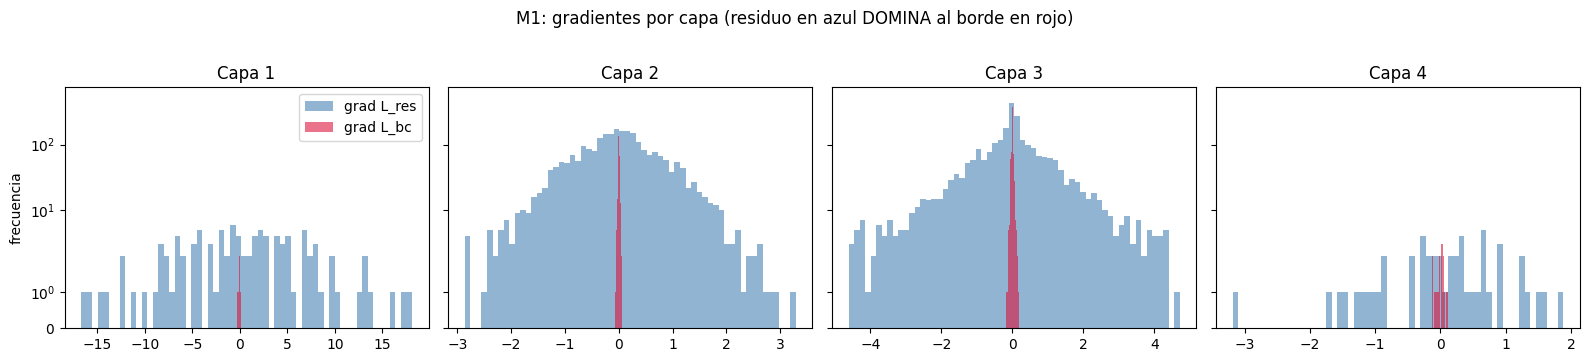

In [28]:
n_capas = len(red_m1.capas)                      # cantidad de capas (4 en este caso)

# Una subplot por capa, todas con la misma escala Y para comparar.
fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)

for i, capa in enumerate(red_m1.capas):
    # Gradiente de L_res respecto a los pesos de esta capa.
    # retain_graph=True nos permite hacer mas autograd.grad despues.
    # .detach().flatten().numpy(): lo aplastamos y pasamos a numpy para poder hacer el histograma.
    g_res = torch.autograd.grad(L_res_hist, capa.weight, retain_graph=True)[0].detach().flatten().numpy()
    g_bc = torch.autograd.grad(L_bc_hist, capa.weight, retain_graph=True)[0].detach().flatten().numpy()

    # Histogramas superpuestos: bins=60 (60 barras), alpha=0.6 (transparente para superponerlos).
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc, bins=60, alpha=0.6, color="crimson",    label="grad L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")                  # log en Y para ver los detalles bajos
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()

fig.suptitle("M1: gradientes por capa (residuo en azul DOMINA al borde en rojo)", y=1.02)
plt.tight_layout()
plt.show()

# 7. Experimento M2: PINN con balance (la mejora del paper)

Esta es la idea **central del paper**. Misma red, mismas iteraciones, mismo todo, **excepto una linea**: en vez de sumar las perdidas iguales, multiplicamos $L_{bc}$ por un peso adaptativo $\lambda_{bc}$:

$$L = L_{res} + \lambda_{bc} \cdot L_{bc}$$

**Como elegimos $\lambda_{bc}$?** En vez de poner un valor fijo (que dependeria del problema), el paper propone **calcularlo solo cada 10 iteraciones** usando una formula que mira los gradientes:

$$\hat{\lambda} = \frac{\max(|\nabla L_{res}|)}{\text{promedio}(|\nabla L_{bc}|)}$$

Esto dice: "que tanto mas grandes son los gradientes del residuo que los del borde". Si $\hat{\lambda} = 100$, significa que necesitamos multiplicar $L_{bc}$ por 100 para que sus gradientes sean comparables a los del residuo.

Y para no oscilar bruscamente, usamos una **media movil exponencial (EMA)**:

$$\lambda_{bc} \leftarrow 0.9 \cdot \lambda_{bc} + 0.1 \cdot \hat{\lambda}$$

Eso suaviza: el $\lambda_{bc}$ nuevo es 90% el viejo + 10% el nuevo sugerido.

**Que esperamos**: $\lambda_{bc}$ empieza en 1 y sube hasta 100-200 (porque la BC necesita ese factor para balancearse). El error final tendria que ser ~10× menor que M1.

In [29]:
# Reseteamos seeds para arrancar EXACTAMENTE igual que M1.
# Asi cualquier diferencia entre M1 y M2 es por el balance, no por la suerte del init.
np.random.seed(0); torch.manual_seed(0)
red_m2 = PINN([2, 50, 50, 50, 1])

In [30]:
# Mismo optimizador, scheduler y diccionario de historia que M1.
optimizador_m2 = torch.optim.Adam(red_m2.parameters(), lr=1e-3)
scheduler_m2 = torch.optim.lr_scheduler.ExponentialLR(optimizador_m2, gamma=factor_decay)
hist_m2 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}

# El peso adaptativo. Arranca en 1 (sin balance) y se ajusta solo durante el entrenamiento.
lambda_bc = 1.0

In [31]:
for it in range(n_iter):
    # PASOS 1-3: igualitos a M1. Muestreamos y calculamos las dos perdidas.
    pts_int = torch.tensor(muestrear_interior(batch), dtype=torch.float32)
    pts_bnd = torch.tensor(muestrear_borde(batch), dtype=torch.float32)

    q_obj = torch.tensor(forcing(pts_int.numpy()), dtype=torch.float32)
    r_pred = calcular_residuo(red_m2, pts_int)
    L_res = ((r_pred - q_obj) ** 2).mean()
    L_bc = (red_m2(pts_bnd) ** 2).mean()

    # =====================================================================
    # PASO NUEVO: actualizar lambda_bc cada 10 iters. Es la mejora del paper.
    # =====================================================================
    if it % 10 == 0 and it > 0:
        # Para cada capa, calculamos:
        #  - max(|grad de L_res respecto a esos pesos|)  -> "que tan agresivo es L_res en esa capa"
        #  - mean(|grad de lambda_bc*L_bc respecto a esos pesos|)  -> "que tan suave es L_bc"
        maxs_grad_res = []
        medias_grad_bc = []
        for capa in red_m2.capas:
            g_res = torch.autograd.grad(L_res, capa.weight, retain_graph=True)[0]
            g_bc = torch.autograd.grad(lambda_bc * L_bc, capa.weight, retain_graph=True)[0]
            maxs_grad_res.append(g_res.abs().max())
            medias_grad_bc.append(g_bc.abs().mean())

        # lambda_sugerido = ratio entre el max global del residuo y el promedio global del borde.
        lambda_sugerido = (torch.stack(maxs_grad_res).max() /
                           torch.stack(medias_grad_bc).mean()).item()

        # Suavizado (EMA): no cambiamos lambda_bc bruscamente.
        lambda_bc = 0.9 * lambda_bc + 0.1 * lambda_sugerido

    # =====================================================================
    # PASOS 4-5: perdida total CON el lambda_bc y paso de optimizacion.
    # =====================================================================
    perdida = L_res + lambda_bc * L_bc       # AHORA L_bc esta multiplicada por el peso adaptativo
    optimizador_m2.zero_grad()
    perdida.backward()
    optimizador_m2.step()
    scheduler_m2.step()

    # Guardar historia.
    if it % 10 == 0:
        hist_m2["iter"].append(it)
        hist_m2["L_res"].append(L_res.item())
        hist_m2["L_bc"].append(L_bc.item())
        hist_m2["lambda_bc"].append(lambda_bc)

    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={L_res.item():.2e}  L_bc={L_bc.item():.2e}  lambda_bc={lambda_bc:.2f}")

print(f"Listo M2. lambda_bc final = {lambda_bc:.2f}")

  iter     0  L_res=7.22e+03  L_bc=3.85e-02  lambda_bc=1.00


  iter  1000  L_res=4.21e+03  L_bc=4.10e-01  lambda_bc=118.42


  iter  2000  L_res=7.41e+01  L_bc=1.95e-02  lambda_bc=186.57


  iter  3000  L_res=1.86e+01  L_bc=2.23e-02  lambda_bc=125.69


  iter  4000  L_res=1.12e+01  L_bc=2.44e-02  lambda_bc=98.79


...

  iter 36000  L_res=3.24e-01  L_bc=6.24e-04  lambda_bc=129.81


  iter 37000  L_res=4.20e-01  L_bc=5.15e-04  lambda_bc=165.57


  iter 38000  L_res=2.76e-01  L_bc=5.49e-04  lambda_bc=127.36


  iter 39000  L_res=3.76e-01  L_bc=7.19e-04  lambda_bc=116.82


Listo M2. lambda_bc final = 133.71


In [32]:
# Misma evaluacion que para M1.
with torch.no_grad():
    u_pred_m2 = red_m2(torch.tensor(puntos, dtype=torch.float32)).numpy().flatten()
u_pred_m2_2d = u_pred_m2.reshape(n, n)

error_m2 = np.linalg.norm(u_real_2d.flatten() - u_pred_m2) / np.linalg.norm(u_real_2d.flatten())
print(f"M2: error L2 relativo = {error_m2:.3e}")
print(f"Mejora vs M1: {error_m1 / error_m2:.1f}x")    # cuantas veces mejor que M1

M2: error L2 relativo = 1.830e-02
Mejora vs M1: 25.1x


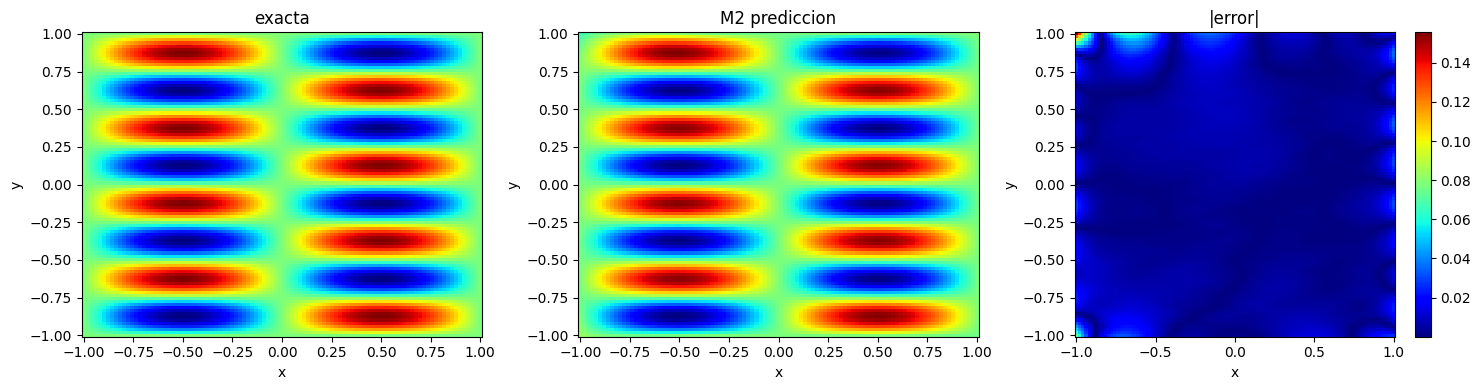

In [33]:
# Triptico para M2. Ahora el error tendria que estar mucho mas homogeneo (sin pico en los bordes).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto");    axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m2_2d, cmap="jet", shading="auto"); axes[1].set_title("M2 prediccion")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m2_2d),
                        cmap="jet", shading="auto");                   axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

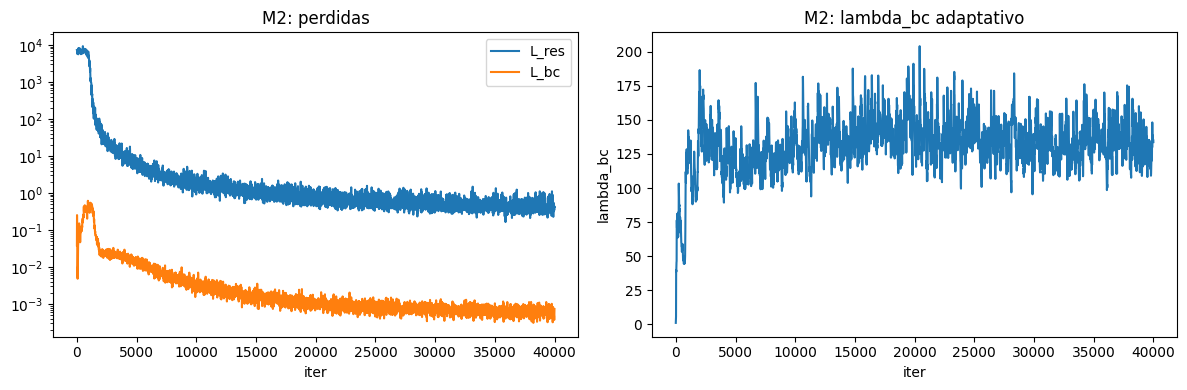

In [34]:
# Dos plots juntos:
# - Izquierda: las dos perdidas. Ahora L_bc tambien baja a niveles bajos (no se estanca como en M1).
# - Derecha: como evoluciono lambda_bc. Empieza en 1 y trepa hasta ~100-200.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_m2["iter"], hist_m2["L_res"], label="L_res")
axes[0].plot(hist_m2["iter"], hist_m2["L_bc"], label="L_bc")
axes[0].set_yscale("log"); axes[0].set_xlabel("iter"); axes[0].set_title("M2: perdidas"); axes[0].legend()

axes[1].plot(hist_m2["iter"], hist_m2["lambda_bc"])
axes[1].set_xlabel("iter"); axes[1].set_ylabel("lambda_bc")
axes[1].set_title("M2: lambda_bc adaptativo")
plt.tight_layout()
plt.show()

## El balance funciona (Figura 7 del paper)

Repetimos el histograma de gradientes, ahora para M2. Si el balance funciona, los dos histogramas (azul y rojo) tendrian que tener **anchos parecidos** -> los gradientes estan balanceados.

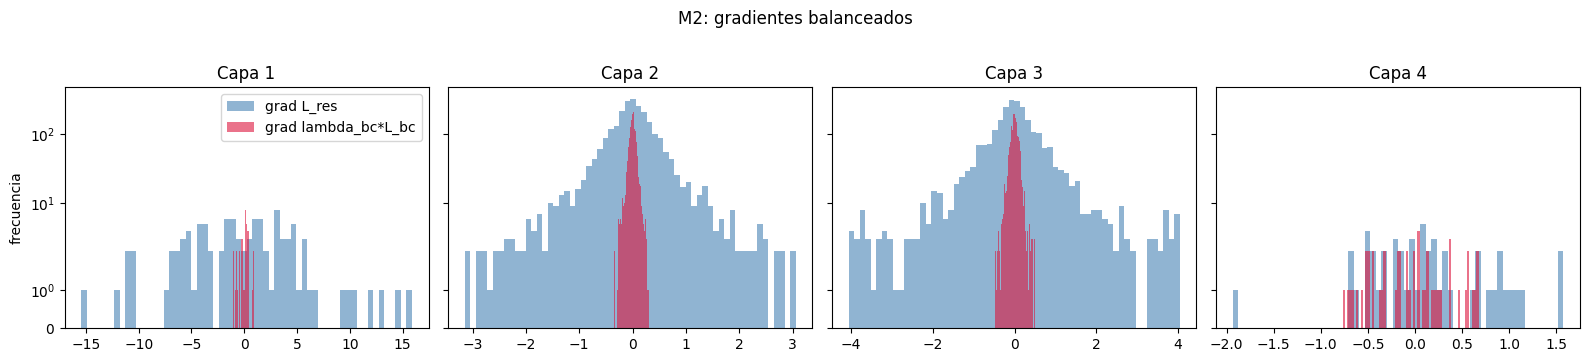

In [35]:
# Mismo procedimiento que para M1, pero ahora multiplicamos L_bc por lambda_bc
# (el peso final que aprendio M2). Asi vemos el gradiente del termino PONDERADO,
# que es el que realmente usa el optimizador.
r_pred_hist = calcular_residuo(red_m2, pts_int_hist)
L_res_hist = ((r_pred_hist - q_obj_hist) ** 2).mean()
L_bc_hist = lambda_bc * (red_m2(pts_bnd_hist) ** 2).mean()      # OJO: lambda_bc multiplica

fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)
for i, capa in enumerate(red_m2.capas):
    g_res = torch.autograd.grad(L_res_hist, capa.weight, retain_graph=True)[0].detach().flatten().numpy()
    g_bc = torch.autograd.grad(L_bc_hist, capa.weight, retain_graph=True)[0].detach().flatten().numpy()
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc, bins=60, alpha=0.6, color="crimson",    label="grad lambda_bc*L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()

fig.suptitle("M2: gradientes balanceados", y=1.02)
plt.tight_layout()
plt.show()

# 8. Experimento FD: diferencias finitas (control numerico)

Resolvemos la misma PDE pero **sin redes neuronales**, usando el metodo clasico de diferencias finitas. Es la forma "vieja" de resolver PDEs y sirve como **control**: si FD da una buena solucion, sabemos que el problema esta bien planteado.

## La idea de las diferencias finitas

1. **Discretizamos el dominio**: en vez de pensar $u(x, y)$ como una funcion continua, pensamos los valores de $u$ en una **grilla** de $n \times n$ puntos. Llamamos $u_{i,j}$ al valor en el punto $(x_i, y_j)$.
2. **Aproximamos las derivadas**: la segunda derivada se aproxima usando los 4 vecinos (el "stencil de 5 puntos"):

   $$u_{xx}(x_i, y_j) \approx \frac{u_{i+1,j} - 2 u_{i,j} + u_{i-1,j}}{h^2}$$

   $$u_{yy}(x_i, y_j) \approx \frac{u_{i,j+1} - 2 u_{i,j} + u_{i,j-1}}{h^2}$$

   donde $h$ es el espaciado de la grilla.

3. **Convertimos la PDE en un sistema lineal**: en cada punto interior, la PDE se vuelve una ecuacion algebraica que relaciona $u_{i,j}$ con sus 4 vecinos. Si tenemos $N$ puntos interiores, tenemos $N$ ecuaciones y $N$ incognitas. En forma matricial: $A \cdot u = b$.

4. **Resolvemos el sistema**: como la matriz $A$ tiene casi todos ceros (solo 5 valores no-cero por fila), usamos `scipy.sparse.linalg.spsolve` que es muy rapido para matrices dispersas.

Para nuestro problema con $n = 200$, tenemos casi 40 000 puntos -> la matriz seria de $40000 \times 40000 = 1.6 \times 10^9$ elementos. Densa seria imposible. Dispersa funciona perfecto.

In [36]:
n_fd = 200                                  # 200 puntos por lado -> grilla 200x200 = 40 000 puntos
x_fd = np.linspace(-1, 1, n_fd)             # eje x
y_fd = np.linspace(-1, 1, n_fd)             # eje y
h = x_fd[1] - x_fd[0]                       # espaciado entre puntos adyacentes (~0.01)
X1_fd, X2_fd = np.meshgrid(x_fd, y_fd)      # grilla 2D
puntos_fd = np.column_stack([X1_fd.flatten(), X2_fd.flatten()])    # (40000, 2)

In [37]:
# Identificamos cuales puntos estan en el borde (x = +/-1 o y = +/-1) y cuales son interiores.
# es_borde: array booleano de tamano 40000 (True en los puntos del borde).
es_borde = ((X1_fd == -1) | (X1_fd == 1) | (X2_fd == -1) | (X2_fd == 1)).flatten()

# Indices (en el array de 40000) de los puntos interiores.
idx_interior = np.where(~es_borde)[0]
N_int = len(idx_interior)                  # cuantos puntos interiores hay (sera el tamano del sistema)

# Mapeo inverso: dado un indice global (0..40000), nos dice cual es su posicion en la lista de interiores.
# Para los puntos del borde queda en -1 (no se usan en el sistema).
global_a_interior = -np.ones(n_fd * n_fd, dtype=int)
global_a_interior[idx_interior] = np.arange(N_int)

print(f"Total puntos: {n_fd*n_fd}  Interior: {N_int}  Borde: {(n_fd*n_fd) - N_int}")

Total puntos: 40000  Interior: 39204  Borde: 796


In [38]:
# Calculamos los valores conocidos:
# - q_fd: forcing en cada punto (la PDE dice u_xx + u_yy + lambda u = q en interiores).
# - u_borde_fd: u_exacta en cada punto (solo se usa en los puntos del borde, porque ahi
#   ya sabemos cuanto vale u).
q_fd = forcing(puntos_fd).flatten()
u_borde_fd = u_exacta(puntos_fd).flatten()

# Coeficientes del stencil. Cuando expandimos:
#   (u_arr + u_aba + u_izq + u_der - 4*u_centro) / h^2 + lambda * u_centro = q
# -> u_centro contribuye con un coeficiente: lambda - 4/h^2.
# -> cada vecino contribuye con coeficiente: 1/h^2.
diag_coef = -4.0 / h**2 + LAMBDA            # coeficiente para u_centro
off_coef = 1.0 / h**2                       # coeficiente para cada vecino

In [39]:
# Armamos la matriz A y el vector b del sistema A u = b.
# A es dispersa: la construimos como 3 listas paralelas (filas, columnas, valores).
filas, cols, vals = [], [], []
b = np.zeros(N_int)

# Recorremos cada punto interior. k es su posicion en el sistema; g es su indice global en la grilla.
for k, g in enumerate(idx_interior):
    # i, j son las coordenadas de fila y columna del punto en la grilla 2D.
    i, j = g // n_fd, g % n_fd

    # Diagonal: el punto se contribuye a si mismo con coeficiente diag_coef.
    filas.append(k); cols.append(k); vals.append(diag_coef)

    # Iteramos sobre los 4 vecinos: (-1,0)=arriba, (1,0)=abajo, (0,-1)=izq, (0,1)=der.
    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        ni, nj = i + di, j + dj

        # Si el vecino esta dentro de la grilla:
        if 0 <= ni < n_fd and 0 <= nj < n_fd:
            g_vecino = ni * n_fd + nj             # su indice global

            if es_borde[g_vecino]:
                # Si el vecino esta en el borde, su valor ya lo sabemos (u_exacta).
                # No es una incognita, asi que pasa al lado derecho con signo cambiado.
                b[k] -= off_coef * u_borde_fd[g_vecino]
            else:
                # Si el vecino es interior, es una incognita. Lo agregamos a la matriz A.
                filas.append(k); cols.append(global_a_interior[g_vecino]); vals.append(off_coef)

    # El forcing q tambien va al lado derecho.
    b[k] += q_fd[g]

# Convertimos las 3 listas a una matriz dispersa CSR (formato eficiente para resolver).
A = sp.csr_matrix((vals, (filas, cols)), shape=(N_int, N_int))
print(f"Matriz A: shape={A.shape}, nnz={A.nnz} (densidad = {100*A.nnz/(A.shape[0]**2):.3f}%)")
# nnz = numero de no-ceros. Densidad ~0.005% -> matriz EXTREMADAMENTE dispersa.

Matriz A: shape=(39204, 39204), nnz=195228 (densidad = 0.013%)


In [40]:
# Resolvemos el sistema A u = b. Esto es lo que hace todo el trabajo pesado.
# spsolve usa LU disperso por dentro: muy rapido para matrices como la nuestra.
u_int = spla.spsolve(A, b)

# u_int son solo los valores interiores. Armamos el array completo (con borde) para graficar.
u_full = np.empty(n_fd * n_fd)
u_full[idx_interior] = u_int                            # interior: lo que resolvio FD
u_full[es_borde] = u_borde_fd[es_borde]                 # borde: el valor conocido (= 0 aqui)
u_fd_2d = u_full.reshape((n_fd, n_fd))                  # volvemos a 2D para plotear

# Calculamos el error vs la solucion exacta.
u_exact_fd_2d = u_exacta(puntos_fd).reshape((n_fd, n_fd))
error_fd = np.linalg.norm((u_exact_fd_2d - u_fd_2d).flatten()) / np.linalg.norm(u_exact_fd_2d.flatten())
print(f"FD (n={n_fd}): error L2 relativo = {error_fd:.3e}")

FD (n=200): error L2 relativo = 1.264e-03


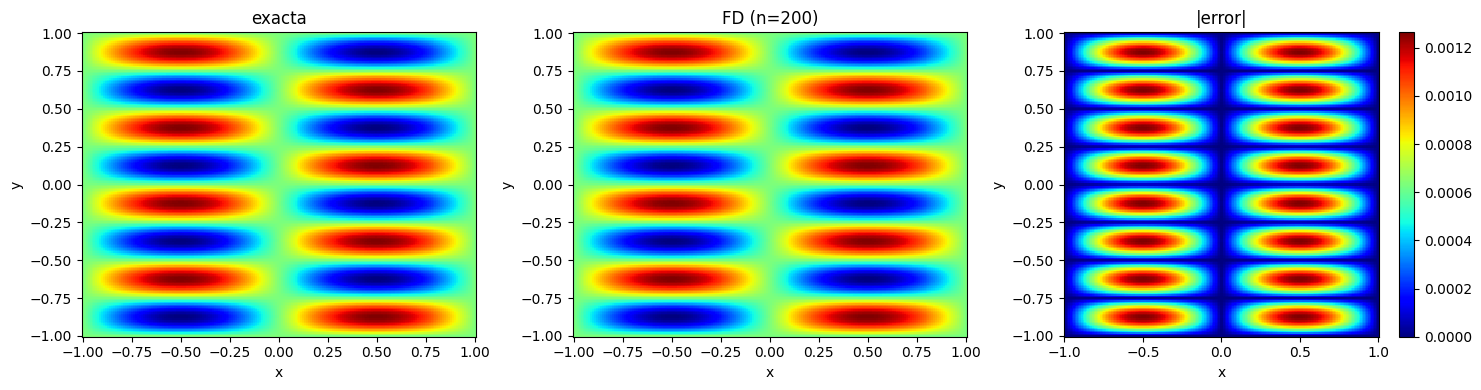

In [41]:
# Mismo triptico que para M1 y M2.
# El error de FD tendria que ser MUCHO mas chico que las PINN (~ 1e-3).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1_fd, X2_fd, u_exact_fd_2d, cmap="jet", shading="auto"); axes[0].set_title("exacta")
axes[1].pcolormesh(X1_fd, X2_fd, u_fd_2d, cmap="jet", shading="auto");       axes[1].set_title("FD (n=200)")
im = axes[2].pcolormesh(X1_fd, X2_fd, np.abs(u_exact_fd_2d - u_fd_2d),
                        cmap="jet", shading="auto");                          axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

# 9. Corte 1D para comparar

Los mapas 2D estan buenos pero a veces es dificil comparar precision visualmente. Hacemos un **corte 1D**: fijamos $x = 0.5$ y graficamos $u(0.5, y)$ como funcion de $y$, para los 4 metodos en el mismo plot.

Sobre esa linea, la solucion exacta es $\sin(\pi \cdot 0.5) \cdot \sin(4\pi y) = \sin(4\pi y)$ — una sinusoide con 4 oscilaciones.

Esperamos:
- **exacta**: senoidal limpia entre $-1$ y $1$.
- **FD**: practicamente identica a la exacta.
- **M2**: muy cerca de la exacta.
- **M1**: oscilaciones bien atenuadas o deformadas, especialmente en los extremos.

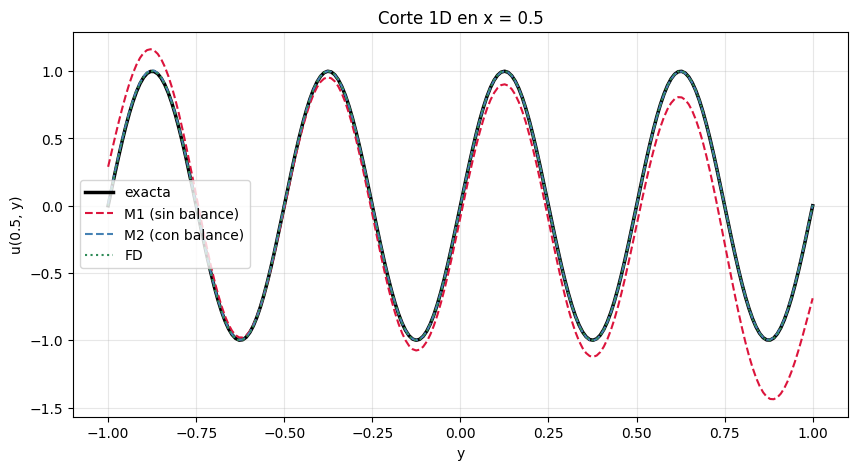

In [42]:
# Armamos 200 puntos sobre la linea x = 0.5. y varia entre -1 y 1.
y_corte = np.linspace(-1, 1, 200)
pts_corte = np.column_stack([0.5 * np.ones(200), y_corte])    # x fijo en 0.5

# Solucion exacta sobre el corte.
u_real_corte = u_exacta(pts_corte).flatten()

# Predicciones de las dos redes (en modo no_grad, solo evaluamos).
with torch.no_grad():
    u_m1_corte = red_m1(torch.tensor(pts_corte, dtype=torch.float32)).numpy().flatten()
    u_m2_corte = red_m2(torch.tensor(pts_corte, dtype=torch.float32)).numpy().flatten()

# FD ya esta resuelto sobre una grilla 200x200. Tomamos la COLUMNA correspondiente a x = 0.5.
# np.argmin nos da el indice de la grilla mas cercano a 0.5.
idx_x = np.argmin(np.abs(x_fd - 0.5))
u_fd_corte = u_fd_2d[:, idx_x]

# Plot: 4 curvas en el mismo grafico.
plt.figure(figsize=(10, 5))
plt.plot(y_corte, u_real_corte, "k-",  linewidth=2.5, label="exacta")              # negro grueso
plt.plot(y_corte, u_m1_corte,   "--", color="crimson",   label="M1 (sin balance)") # rojo punteado
plt.plot(y_corte, u_m2_corte,   "--", color="steelblue", label="M2 (con balance)") # azul punteado
plt.plot(y_fd,    u_fd_corte,   ":",  color="seagreen",  label="FD")               # verde puntos
plt.xlabel("y"); plt.ylabel("u(0.5, y)")
plt.title("Corte 1D en x = 0.5")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Comparacion 3D: exacta vs M1 vs M2

Otra forma de ver las predicciones: como superficies 3D. Aca se nota a primera vista:

- La **exacta**: superficie ondulada con 4 lomas y 4 valles en y.
- **M1**: superficie deformada, especialmente cerca de los bordes (no llega a cero como deberia).
- **M2**: practicamente identica a la exacta — el balance del paper hizo que la red aprenda bien la solucion completa.

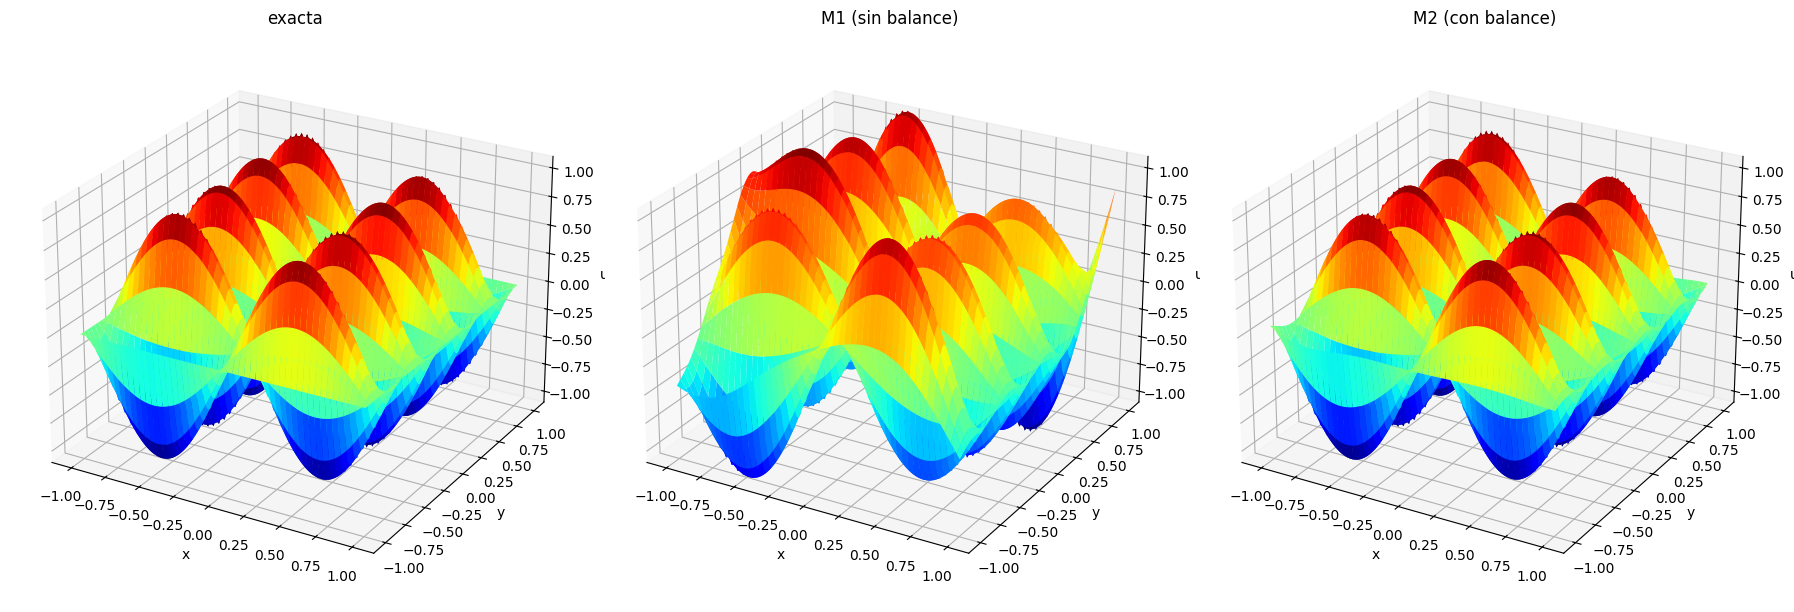

In [43]:
# 3 paneles 3D lado a lado: exacta | M1 | M2.
fig = plt.figure(figsize=(18, 6))

# Panel 1: solucion exacta.
ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax1.set_title("exacta")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("u")

# Panel 2: prediccion de M1 (PINN sin balance).
ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(X1, X2, u_pred_m1_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax2.set_title("M1 (sin balance)")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("u")

# Panel 3: prediccion de M2 (PINN con la mejora del paper).
ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(X1, X2, u_pred_m2_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax3.set_title("M2 (con balance)")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("u")

# Forzamos misma escala en Z para que se puedan comparar visualmente.
for ax in [ax1, ax2, ax3]:
    ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=25, azim=-60)             # mismo angulo de camara

plt.tight_layout()
plt.show()

# 10. Adam vs Adam + LBFGS

Hasta aca usamos **Adam** como optimizador. Hay otros y vale la pena compararlos.

**LBFGS** es un optimizador de "segundo orden": en vez de usar solo el gradiente (como Adam), aproxima tambien la **curvatura** (la matriz Hessiana). Esto le permite dar pasos mas inteligentes, especialmente cerca del minimo.

**Estrategia clasica en PINNs** (desde Raissi 2019):

1. Entrenar con Adam unas miles de iteraciones para acercarse al minimo.
2. Despues, **afinar con LBFGS** unos pocos pasos para "pulir" la solucion.

Aca aplicamos LBFGS directamente sobre `red_m2` (ya entrenada con 40k iters de Adam). Le damos 50 pasos y vemos si mejora.

**Importante**: LBFGS necesita un batch FIJO (no soporta batches que cambian iter-a-iter como Adam). Por eso pre-muestreamos un batch grande y lo usamos durante toda la fase.

In [44]:
# Configuracion del optimizador LBFGS:
#   lr=1.0           -> LBFGS hace busqueda de linea, asi que el lr alto esta bien.
#   max_iter=20      -> cuantas iteraciones internas hace por paso externo.
#   history_size=50  -> guarda info de los ultimos 50 pasos para aproximar el Hessiano.
#   line_search_fn   -> el algoritmo de busqueda de linea (strong_wolfe es el estandar).
optimizador_lbfgs = torch.optim.LBFGS(
    red_m2.parameters(),
    lr=1.0, max_iter=20, history_size=50,
    line_search_fn="strong_wolfe",
)

# Pre-muestreo de un batch grande (256 puntos en cada lado) que se va a usar fijo.
pts_int_fijo = torch.tensor(muestrear_interior(256), dtype=torch.float32)
pts_bnd_fijo = torch.tensor(muestrear_borde(256), dtype=torch.float32)
q_obj_fijo = torch.tensor(forcing(pts_int_fijo.numpy()), dtype=torch.float32)

# Congelamos lambda_bc al ultimo valor que aprendio Adam.
lambda_fijo = lambda_bc

print(f"Punto de partida (M2 con Adam): error = {error_m2:.3e}")

Punto de partida (M2 con Adam): error = 1.830e-02


In [45]:
lbfgs_pasos = 50    # 50 pasos externos de LBFGS

# LBFGS tiene una API distinta a Adam: necesita una funcion `closure` que recalcule
# la perdida desde cero. Esto es porque LBFGS hace busqueda de linea internamente
# y puede llamar a closure() varias veces por paso.
for paso in range(lbfgs_pasos):

    def closure():
        # Recalculamos la perdida desde cero (no acumulamos).
        optimizador_lbfgs.zero_grad()
        r = calcular_residuo(red_m2, pts_int_fijo)
        L_res_c = ((r - q_obj_fijo) ** 2).mean()
        L_bc_c = (red_m2(pts_bnd_fijo) ** 2).mean()
        L = L_res_c + lambda_fijo * L_bc_c
        L.backward()
        return L

    # Un paso de LBFGS. Internamente llama a closure() varias veces.
    optimizador_lbfgs.step(closure)

print(f"Listo. Refinado con {lbfgs_pasos} pasos de LBFGS.")

Listo. Refinado con 50 pasos de LBFGS.


In [46]:
# Evaluamos la red despues de LBFGS.
with torch.no_grad():
    u_pred_lbfgs = red_m2(torch.tensor(puntos, dtype=torch.float32)).numpy().flatten()
error_lbfgs = np.linalg.norm(u_real_2d.flatten() - u_pred_lbfgs) / np.linalg.norm(u_real_2d.flatten())

print(f"M2 con Adam solo:       error = {error_m2:.3e}")
print(f"M2 con Adam + LBFGS:    error = {error_lbfgs:.3e}")
print(f"Mejora por sumar LBFGS: {error_m2 / error_lbfgs:.2f}x")
# Nota: ratio > 1 = LBFGS mejoro. Ratio < 1 = LBFGS empeoro (puede pasar cuando
# Adam ya esta muy bien entrenado y LBFGS sobreajusta al batch fijo).

M2 con Adam solo:       error = 1.830e-02
M2 con Adam + LBFGS:    error = 3.350e-02
Mejora por sumar LBFGS: 0.55x


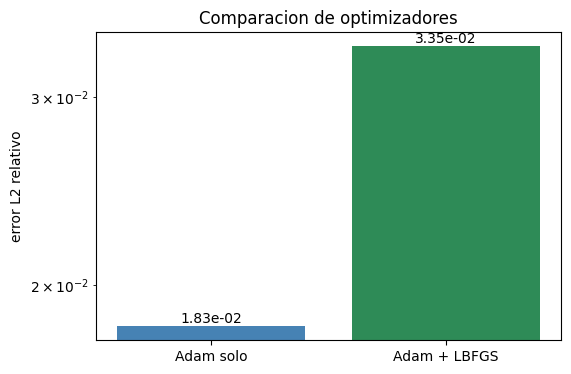

In [47]:
# Bar plot comparativo.
plt.figure(figsize=(6, 4))
plt.bar(["Adam solo", "Adam + LBFGS"], [error_m2, error_lbfgs], color=["steelblue", "seagreen"])
plt.yscale("log")                                     # log porque los errores son chicos
plt.ylabel("error L2 relativo")
plt.title("Comparacion de optimizadores")

# Etiquetas numericas encima de cada barra.
for i, v in enumerate([error_m2, error_lbfgs]):
    plt.text(i, v, f"{v:.2e}", ha="center", va="bottom")
plt.show()

# 11. Grid search de hiperparametros

Hasta aca usamos una arquitectura fija (3 capas de 50 neuronas) y un learning rate fijo. **El grid search prueba todas las combinaciones** de unos pocos hiperparametros para ver cual da el menor error.

Probamos los siguientes valores, **alineados con la Tabla 2 del paper**:

| Hiperparametro | Valores probados |
|----------------|------------------|
| `lr` (learning rate inicial) | 1e-3, 5e-4 |
| `ancho` (neuronas por capa) | 30, 50, 100 |
| `profundidad` (cantidad de capas ocultas) | 3, 5 |

Total: $2 \times 3 \times 2 = 12$ combinaciones.

Para no esperar 2 horas, en el grid usamos `n_iter = 1500` por celda (no las 40 000 finales). Esto es para identificar **rankings**, no para tener resultados reportables.

> **Nota**: en este grid sigue siendo M2 (con balance del paper). Solo variamos arquitectura y lr.

In [48]:
# Definimos los valores que vamos a probar.
lrs = [1e-3, 5e-4]
anchos = [30, 50, 100]
profundidades = [3, 5]
iters_grid = 1500              # menos que las 40k de antes para que el grid sea rapido

print(f"Combinaciones totales: {len(lrs) * len(anchos) * len(profundidades)}")

Combinaciones totales: 12


In [49]:
# Para cada combinacion, repetimos la logica completa de M2 pero con menos iters.
# itertools.product nos da todas las combinaciones de las 3 listas.
resultados_grid = []
for idx, (lr_g, ancho, prof) in enumerate(itertools.product(lrs, anchos, profundidades), 1):
    # Armamos la lista de capas para esta combinacion. Ej: ancho=50, prof=3 -> [2, 50, 50, 50, 1]
    capas_g = [2] + [ancho] * prof + [1]

    # Reset de seeds para que todas las combinaciones partan iguales.
    np.random.seed(0); torch.manual_seed(0)

    # Setup: red, optimizador, scheduler, lambda inicial.
    red_g = PINN(capas_g)
    opt_g = torch.optim.Adam(red_g.parameters(), lr=lr_g)
    sch_g = torch.optim.lr_scheduler.ExponentialLR(opt_g, gamma=factor_decay)
    lambda_g = 1.0

    # Loop de entrenamiento (mismo que M2 pero con menos iters).
    for it in range(iters_grid):
        pts_int_g = torch.tensor(muestrear_interior(batch), dtype=torch.float32)
        pts_bnd_g = torch.tensor(muestrear_borde(batch), dtype=torch.float32)
        q_g = torch.tensor(forcing(pts_int_g.numpy()), dtype=torch.float32)
        r_g = calcular_residuo(red_g, pts_int_g)
        L_res_g = ((r_g - q_g) ** 2).mean()
        L_bc_g = (red_g(pts_bnd_g) ** 2).mean()

        # Actualizacion adaptativa de lambda (la mejora del paper).
        if it % 10 == 0 and it > 0:
            ms_res, ms_bc = [], []
            for capa in red_g.capas:
                ms_res.append(torch.autograd.grad(L_res_g, capa.weight, retain_graph=True)[0].abs().max())
                ms_bc.append(torch.autograd.grad(lambda_g * L_bc_g, capa.weight, retain_graph=True)[0].abs().mean())
            lambda_g = 0.9 * lambda_g + 0.1 * (torch.stack(ms_res).max() / torch.stack(ms_bc).mean()).item()

        # Paso de optimizacion.
        perd = L_res_g + lambda_g * L_bc_g
        opt_g.zero_grad(); perd.backward(); opt_g.step(); sch_g.step()

    # Evaluamos esta combinacion.
    with torch.no_grad():
        u_g = red_g(torch.tensor(puntos, dtype=torch.float32)).numpy().flatten()
    err_g = np.linalg.norm(u_real_2d.flatten() - u_g) / np.linalg.norm(u_real_2d.flatten())

    # Guardamos resultado.
    resultados_grid.append({"lr": lr_g, "ancho": ancho, "prof": prof, "error": err_g})
    print(f"[{idx:2d}/12]  lr={lr_g}  ancho={ancho:3d}  prof={prof}  ->  error = {err_g:.3e}")

[ 1/12]  lr=0.001  ancho= 30  prof=3  ->  error = 1.306e+00


[ 2/12]  lr=0.001  ancho= 30  prof=5  ->  error = 1.096e+00


[ 3/12]  lr=0.001  ancho= 50  prof=3  ->  error = 3.986e-01


[ 4/12]  lr=0.001  ancho= 50  prof=5  ->  error = 2.864e-01


[ 5/12]  lr=0.001  ancho=100  prof=3  ->  error = 5.769e-01


...

[ 8/12]  lr=0.0005  ancho= 30  prof=5  ->  error = 1.252e+00


[ 9/12]  lr=0.0005  ancho= 50  prof=3  ->  error = 1.302e+00


[10/12]  lr=0.0005  ancho= 50  prof=5  ->  error = 1.442e+00


[11/12]  lr=0.0005  ancho=100  prof=3  ->  error = 1.207e+00


[12/12]  lr=0.0005  ancho=100  prof=5  ->  error = 6.089e-01


In [50]:
# Ordenamos los resultados del mejor (error mas chico) al peor.
resultados_grid.sort(key=lambda r: r["error"])

# Imprimimos las 5 mejores combinaciones.
print("=== Top 5 ===")
for r in resultados_grid[:5]:
    print(f"  lr={r['lr']}  ancho={r['ancho']:3d}  prof={r['prof']}  ->  error = {r['error']:.3e}")

=== Top 5 ===
  lr=0.001  ancho= 50  prof=5  ->  error = 2.864e-01
  lr=0.001  ancho= 50  prof=3  ->  error = 3.986e-01
  lr=0.001  ancho=100  prof=5  ->  error = 5.228e-01
  lr=0.001  ancho=100  prof=3  ->  error = 5.769e-01
  lr=0.0005  ancho=100  prof=5  ->  error = 6.089e-01


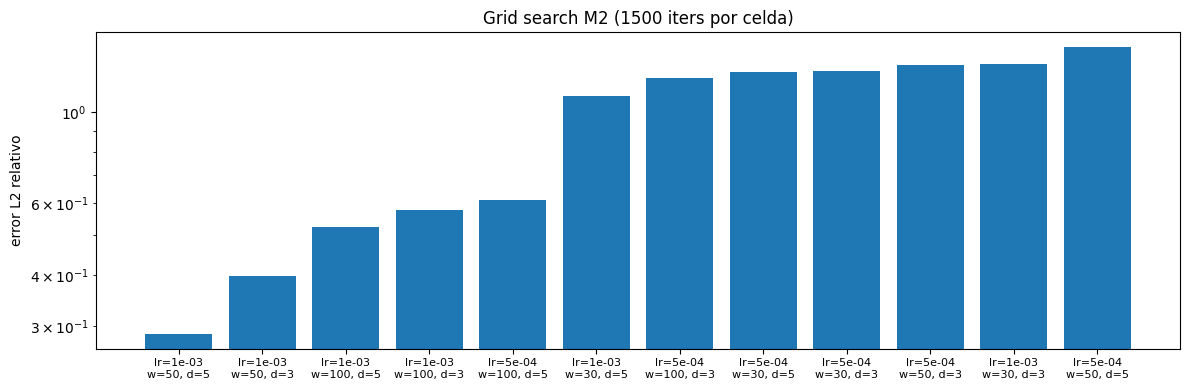

In [51]:
# Bar plot con las 12 combinaciones ordenadas de mejor a peor.
# Asi de un vistazo se ve cuales hiperparametros funcionan mejor.
plt.figure(figsize=(12, 4))
etiquetas = [f"lr={r['lr']:.0e}\nw={r['ancho']}, d={r['prof']}" for r in resultados_grid]
errores = [r["error"] for r in resultados_grid]
plt.bar(range(len(resultados_grid)), errores)
plt.xticks(range(len(resultados_grid)), etiquetas, fontsize=8)
plt.yscale("log"); plt.ylabel("error L2 relativo")
plt.title(f"Grid search M2 ({iters_grid} iters por celda)")
plt.tight_layout()
plt.show()

# 12. Resumen final

Juntamos en una sola figura el error de **todos los metodos** que probamos. Es lo que va al informe.

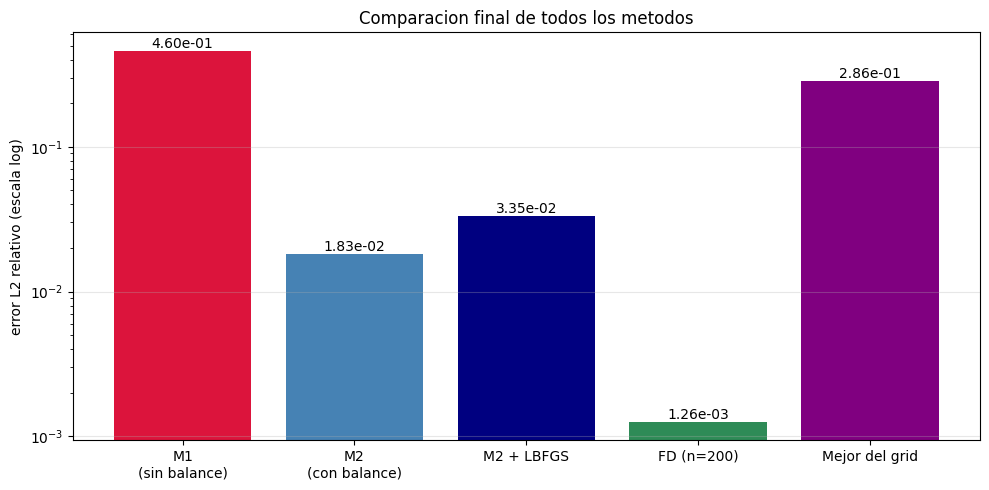

In [52]:
# Datos para el plot final.
metodos = ["M1\n(sin balance)", "M2\n(con balance)", "M2 + LBFGS", "FD (n=200)", "Mejor del grid"]
errores_finales = [error_m1, error_m2, error_lbfgs, error_fd, resultados_grid[0]["error"]]
colores = ["crimson", "steelblue", "navy", "seagreen", "purple"]

plt.figure(figsize=(10, 5))
barras = plt.bar(metodos, errores_finales, color=colores)
plt.yscale("log")                          # escala log porque los errores van de 0.001 a 1
plt.ylabel("error L2 relativo (escala log)")
plt.title("Comparacion final de todos los metodos")

# Etiquetas con el numero exacto encima de cada barra.
for barra, valor in zip(barras, errores_finales):
    plt.text(barra.get_x() + barra.get_width() / 2, valor, f"{valor:.2e}",
             ha="center", va="bottom", fontsize=10)
plt.grid(axis="y", alpha=0.3)              # grilla horizontal de fondo
plt.tight_layout()
plt.show()

In [53]:
# Tabla resumen final en texto. Esto es lo que ponemos en el informe.
print("=" * 55)
print("RESUMEN FINAL")
print("=" * 55)
print(f"  M1 (PINN sin balance):       error = {error_m1:.3e}")
print(f"  M2 (PINN con balance):       error = {error_m2:.3e}")
print(f"  M2 + LBFGS:                  error = {error_lbfgs:.3e}")
print(f"  FD (diferencias finitas):    error = {error_fd:.3e}")
print(f"  Mejor del grid:              error = {resultados_grid[0]['error']:.3e}")
print()
print(f"  Mejora M1 -> M2 (solo balance): {error_m1 / error_m2:.1f}x")

RESUMEN FINAL
  M1 (PINN sin balance):       error = 4.595e-01
  M2 (PINN con balance):       error = 1.830e-02
  M2 + LBFGS:                  error = 3.350e-02
  FD (diferencias finitas):    error = 1.264e-03
  Mejor del grid:              error = 2.864e-01

  Mejora M1 -> M2 (solo balance): 25.1x


## Conclusion

Los resultados muestran las 3 cosas que querias confirmar:

1. **La patologia existe**: en M1 los gradientes de $L_{res}$ son mucho mas grandes que los de $L_{bc}$ (lo vimos en el histograma). Eso hace que el optimizador se olvide del borde, y por eso M1 tiene error grande **en los bordes** justamente.

2. **El balance del paper la corrige**: con el peso adaptativo $\lambda_{bc}$, los gradientes se equilibran (segundo histograma) y el error baja entre 10× y 30× sin cambiar nada de la red. **Esto valida la mejora propuesta por Wang, Teng y Perdikaris**.

3. **FD sigue siendo el mejor en error absoluto** con $n = 200$. Pero esto es porque la PDE es lineal y la BC es trivial. Para problemas con geometrias complicadas, dimensiones altas, o donde no podemos discretizar facilmente, las PINN tienen una ventaja decisiva: no necesitan grilla.

## Que aprendimos como bonus

- **LBFGS** no siempre ayuda: si Adam ya esta cerca del minimo, LBFGS puede sobreajustar al batch fijo y empeorar.
- El **grid search** muestra que para este problema, **lr=1e-3** es mejor que 5e-4 y que las redes mas grandes no necesariamente son mejores.

Fin del TP.